In [1]:
import pandas as pd
import os
from utils.ml_utils_v2 import EmissionsPredictionPipeline
from utils.eda_utils import EDAUtils, DataCleaningUtils
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")

In [4]:
TRAINING_DATA_PATH = os.path.join(TRAINING_DIR_PATH, "training_data_w_suffix.csv") #NOTE: update filename as needed
training_df = pd.read_csv(TRAINING_DATA_PATH)
training_df = training_df.drop(columns=["primary_id", "future_id"])
training_df.head()

,group_9_L_,group_10_L_Fraction Non-Fugitive :math:\text{CH}_4 Flared,group_24_L_Livestock Manure Management Fraction,group_44_L_Transportation Mode Fuel Fraction,group_45_L_Freight Transportation Mode Share,group_30_L_Industrial :math:\text{CO}_2 Capture Prevalence,group_28_L_Carrying Capacity Scalar,group_33_L_SCOE Efficiency Factor for Heat Energy from Solid Biomass,group_15_L_Clinker Fraction of Cement,group_11_L_Forest Sequestration Emission Factor,...,group_40_L_Average Passenger Vehicle Occupancy Rate,group_18_L_PFC-,group_55_L_Fraction of Landfill Gas Recovered at Landfills,group_35_L_Liming Demand Scalar,group_43_L_Transportation Mode Fuel Fraction,group_23_L_Biogas Recovery Factor at LSMM Anaerobic Facilities,group_37_L_Transportation Demand Scalar,group_51_L_Treatment Fraction,group_59_L_Fraction of Waste Recycled,emission_total
0,0.373986,0.024119,0.538583,0.345412,0.055164,0.927934,0.257369,0.274968,0.987404,0.033033,...,0.564638,0.680266,0.678094,0.967606,0.643369,0.255837,0.604219,0.426574,0.912996,10674.108111
1,0.896463,0.074430,0.632658,0.590931,0.099609,0.422740,0.592655,0.176500,0.643857,0.759073,...,0.726734,0.902547,0.316747,0.673351,0.705113,0.710315,0.044720,0.158652,0.934239,10968.158533
2,0.698922,0.595067,0.973150,0.874385,0.341202,0.716014,0.853154,0.118951,0.453748,0.990036,...,0.536400,0.589297,0.082951,0.410823,0.609188,0.600763,0.989835,0.205757,0.945656,12106.291437
3,0.113597,0.948863,0.778128,0.077945,0.617341,0.473497,0.942894,0.580326,0.463553,0.233395,...,0.237717,0.203194,0.497596,0.774451,0.597047,0.244681,0.902745,0.070456,0.966384,9998.878198
4,0.628671,0.190891,0.057006,0.366491,0.350599,0.072427,0.157005,0.804465,0.295609,0.449043,...,0.542677,0.810124,0.130924,0.409055,0.168156,0.913753,0.030365,0.980789,0.911871,13064.774319


In [5]:
# print(sorted([col for col in training_df.columns if "_L_" in col]))

## EDA

In [6]:
edau = EDAUtils()

In [7]:
target_col = "emission_total"

In [8]:
lhs_group_cols = training_df.drop(columns=[target_col]).columns.tolist()

In [9]:
training_df[target_col].describe()

count      972.000000
mean     10970.834969
std        954.500428
min       8431.786166
25%      10270.684768
50%      10930.704459
75%      11627.824778
max      14101.509546
Name: emission_total, dtype: float64

In [10]:
for col in training_df.columns:
    nans = training_df[col].isna().sum()
    neg_infs = (training_df[col] == -np.inf).sum()
    pos_infs = (training_df[col] == np.inf).sum()
    if nans > 0 or neg_infs > 0 or pos_infs > 0:
        print(f"WARNING: Column '{col}' has {nans} NaNs, {neg_infs} -inf, {pos_infs} inf values.")

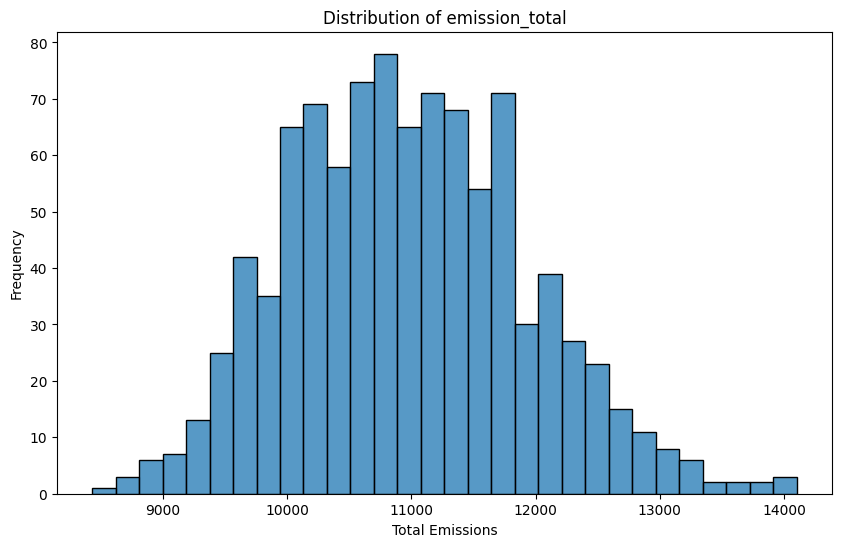

In [11]:
edau.plot_emissions_histogram(training_df, "emission_total", title="Distribution of emission_total", kde=False)

In [12]:
edau.get_target_var_corr(training_df, "emission_total", exclude_cols=target_col)


Correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------
group_62_X_gdp_mmm_usd         : 0.7346
group_34_L_SCOE Fraction Heat Energy Demand  : 0.3314
group_4_L_Crop Yield Factor    : 0.2488
group_31_L_SCOE Heat Energy Demand Scalar : 0.2487
group_27_L_:math:\text{CH}_4 Enteric Fermentation Emission Factor : 0.2142
group_65_X_population_gnrl     : 0.1967
group_29_L_Fraction Eating Red Meat : 0.1808
group_19_L_Unadjusted Land Use Transition Probability : 0.1761
group_39_L_Fuel Efficiency     : 0.1615
group_42_L_Transportation Mode Fuel Fraction  : 0.1525
group_37_L_Transportation Demand Scalar : 0.1108



In [13]:
# Outlier inspection
outliers = edau.find_outlier_columns(training_df, method="iqr", factor=1.5)
print("Outlier percentages:", outliers)
outliers = edau.find_outlier_columns(training_df, method="zscore", z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {'emission_total': 0.51}
Outlier percentages: {'emission_total': 0.41}


## Data Cleaning

In [14]:
dcu = DataCleaningUtils()

In [15]:
training_df.shape

(972, 69)

In [16]:
# # Check those -inf values in technical_cost
# technical_cost_neg_inf = training_df[training_df["technical_cost"] == -np.inf]
# technical_cost_neg_inf

In [17]:
# # filter out -inf values in technical_cost
# training_df = training_df[training_df["technical_cost"] != -np.inf]
# training_df.shape

In [18]:
training_df_cleaned = dcu.remove_outliers(training_df, method="zscore", z_thresh=3.0)
print("Shape before removing outliers:", training_df.shape)
print("Shape after removing outliers:", training_df_cleaned.shape)

Shape before removing outliers: (972, 69)
Shape after removing outliers: (968, 69)


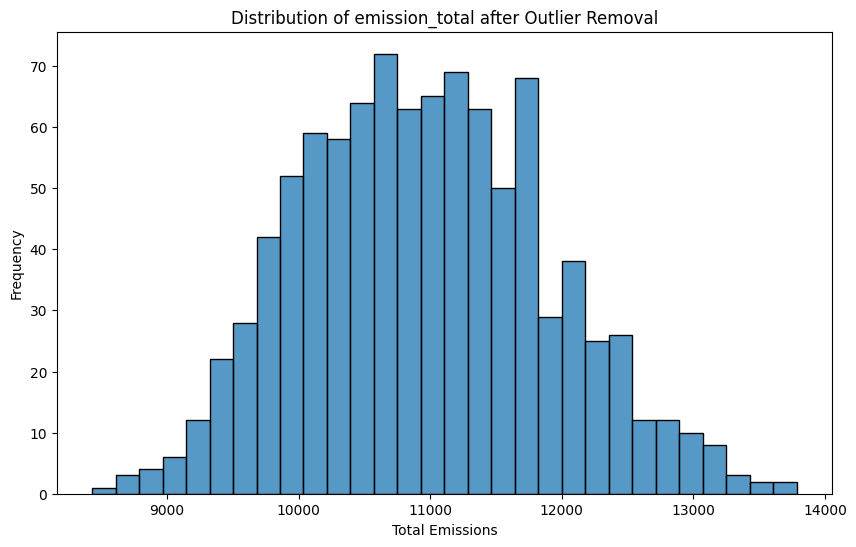

In [19]:
edau.plot_emissions_histogram(training_df_cleaned,
                              column="emission_total",
                              title="Distribution of emission_total after Outlier Removal",
                              kde=False)

In [20]:
outliers = edau.find_outlier_columns(training_df_cleaned, method="zscore", z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {'emission_total': 0.1}


In [21]:
edau.get_target_var_corr(training_df, "emission_total", exclude_cols="emission_total")


Correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------
group_62_X_gdp_mmm_usd         : 0.7346
group_34_L_SCOE Fraction Heat Energy Demand  : 0.3314
group_4_L_Crop Yield Factor    : 0.2488
group_31_L_SCOE Heat Energy Demand Scalar : 0.2487
group_27_L_:math:\text{CH}_4 Enteric Fermentation Emission Factor : 0.2142
group_65_X_population_gnrl     : 0.1967
group_29_L_Fraction Eating Red Meat : 0.1808
group_19_L_Unadjusted Land Use Transition Probability : 0.1761
group_39_L_Fuel Efficiency     : 0.1615
group_42_L_Transportation Mode Fuel Fraction  : 0.1525
group_37_L_Transportation Demand Scalar : 0.1108



In [28]:
# edau.plot_multiple_histograms(training_df_cleaned, training_df_cleaned.drop(columns=["emission_total"]).columns.tolist(), bins=30, kde=False)

In [22]:
# training_df_cleaned[target_cols].describe()

In [23]:
# sns.pairplot(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

In [24]:
# edau.plot_correlation_matrix(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

## ML

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGB hyperparameters: {'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 0.01, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0.0, 'colsample_bytree': 0.5}
Trained reduced model 'XGB_top10' with 10 features.
Trained reduced model 'XGB_top5' with 5 features.
XGB             → MAE: 187.4189, RMSE: 237.7682, R²: 0.9350, SMAPE: 1.7%
MeanBaseline    → MAE: 751.1521, RMSE: 932.3945, R²: -0.0000, SMAPE: 6.9%
MedianBaseline  → MAE: 756.6913, RMSE: 934.8962, R²: -0.0054, SMAPE: 6.9%
RandomForest    → MAE: 333.8884, RMSE: 422.8242, R²: 0.7944, SMAPE: 3.1%
ElasticNet      → MAE: 286.5283, RMSE: 360.5689, R²: 0.8505, SMAPE: 2.6%
XGB_top10       → MAE: 224.2918, RMSE: 275.4295, R²: 0.9127, SMAPE: 2.1%
XGB_top5        → MAE: 349.9066, RMSE: 434.8739, R²: 0.7825, SMAPE: 3.2%


/opt/miniconda3/envs/ssp_uganda_env/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/miniconda3/envs/ssp_uganda_env/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/miniconda3/envs/ssp_uganda_env/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_



=== CV Results for XGB ===
MAE: 197.6775 ± 8.7406
R2: 0.9277 ± 0.0073
RMSE: 250.5022 ± 11.1581

=== CV Results for XGB_top10 ===
MAE: 220.3469 ± 18.2378
R2: 0.9092 ± 0.0132
RMSE: 280.1541 ± 18.7132

=== CV Results for XGB_top5 ===
MAE: 351.7003 ± 6.7017
R2: 0.7761 ± 0.0072
RMSE: 441.4731 ± 13.2861
Best XGB variant by MAE: XGB


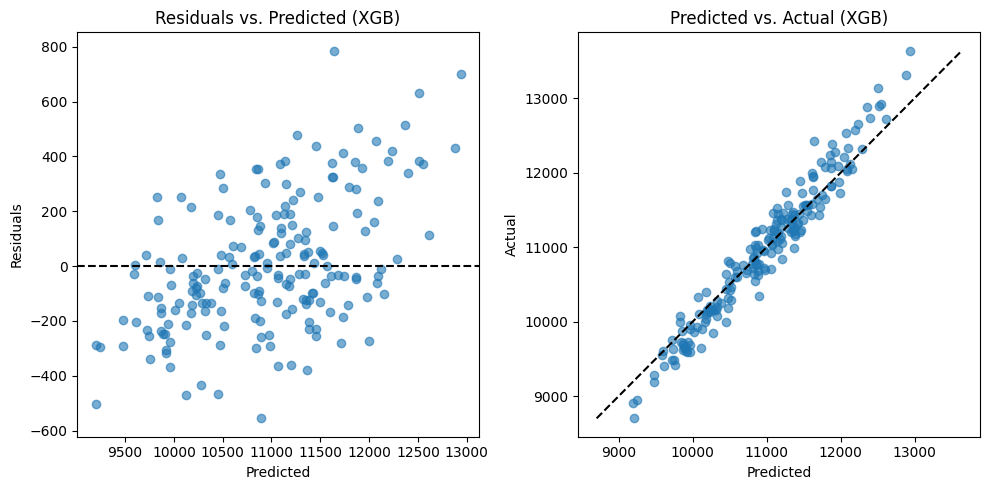

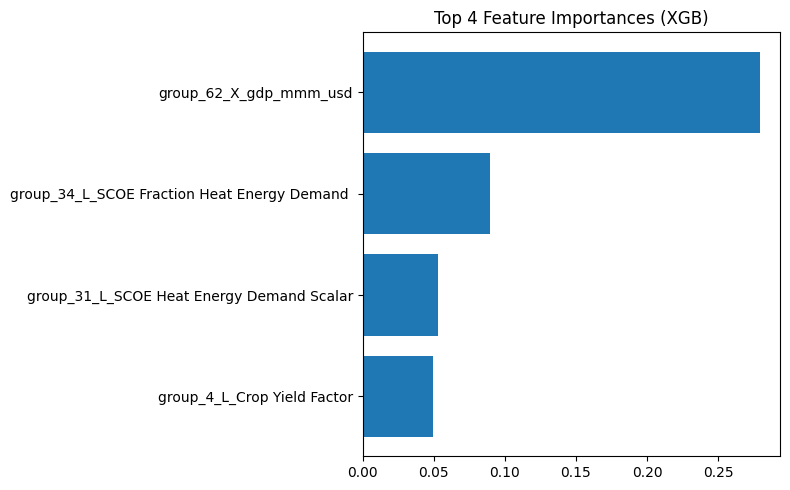

In [47]:
pipe = EmissionsPredictionPipeline(training_df_cleaned, target="emission_total")
pipe.run(
    tune=True,
    log_transform=False,     # or True if your target is skewed
    cv_splits=5,
    create_plots=True,
    train_reduced=True,      # trains XGB_top10 and XGB_top5
    reduced_ks=[10, 5]
)

# # Compare and pick best variant (among XGB, XGB_top10, XGB_top5)
# comparison = pipe.compare_xgb_variants(metric="MAE")
# print(comparison)
# best_model_name = pipe.select_best_xgb(metric="MAE")

# # Predict with the selected reduced model
# y_hat = pipe.predict(new_data=df_inference, model_name=best_model_name)


In [48]:

# Compare and pick best variant (among XGB, XGB_top10, XGB_top5)
comparison = pipe.compare_xgb_variants(metric="MAE")
print(comparison)
best_model_name = pipe.select_best_xgb(metric="MAE")

       Model         MAE        RMSE        R2     SMAPE
0        XGB  187.418865  237.768152  0.934971  1.705472
5  XGB_top10  224.291808  275.429539  0.912739  2.050952
6   XGB_top5  349.906578  434.873869  0.782466  3.201749
Best XGB variant by MAE: XGB


## Save the trained and tuned model and use it to predict new data

In [49]:
training_df_cleaned.head()

,group_9_L_,group_10_L_Fraction Non-Fugitive :math:\text{CH}_4 Flared,group_24_L_Livestock Manure Management Fraction,group_44_L_Transportation Mode Fuel Fraction,group_45_L_Freight Transportation Mode Share,group_30_L_Industrial :math:\text{CO}_2 Capture Prevalence,group_28_L_Carrying Capacity Scalar,group_33_L_SCOE Efficiency Factor for Heat Energy from Solid Biomass,group_15_L_Clinker Fraction of Cement,group_11_L_Forest Sequestration Emission Factor,...,group_40_L_Average Passenger Vehicle Occupancy Rate,group_18_L_PFC-,group_55_L_Fraction of Landfill Gas Recovered at Landfills,group_35_L_Liming Demand Scalar,group_43_L_Transportation Mode Fuel Fraction,group_23_L_Biogas Recovery Factor at LSMM Anaerobic Facilities,group_37_L_Transportation Demand Scalar,group_51_L_Treatment Fraction,group_59_L_Fraction of Waste Recycled,emission_total
0,0.373986,0.024119,0.538583,0.345412,0.055164,0.927934,0.257369,0.274968,0.987404,0.033033,...,0.564638,0.680266,0.678094,0.967606,0.643369,0.255837,0.604219,0.426574,0.912996,10674.108111
1,0.896463,0.074430,0.632658,0.590931,0.099609,0.422740,0.592655,0.176500,0.643857,0.759073,...,0.726734,0.902547,0.316747,0.673351,0.705113,0.710315,0.044720,0.158652,0.934239,10968.158533
2,0.698922,0.595067,0.973150,0.874385,0.341202,0.716014,0.853154,0.118951,0.453748,0.990036,...,0.536400,0.589297,0.082951,0.410823,0.609188,0.600763,0.989835,0.205757,0.945656,12106.291437
3,0.113597,0.948863,0.778128,0.077945,0.617341,0.473497,0.942894,0.580326,0.463553,0.233395,...,0.237717,0.203194,0.497596,0.774451,0.597047,0.244681,0.902745,0.070456,0.966384,9998.878198
4,0.628671,0.190891,0.057006,0.366491,0.350599,0.072427,0.157005,0.804465,0.295609,0.449043,...,0.542677,0.810124,0.130924,0.409055,0.168156,0.913753,0.030365,0.980789,0.911871,13064.774319


In [50]:
# Get a single row from training_df_cleaned for prediction
single_row = training_df_cleaned.iloc[0].drop(columns="emission_total")
single_row = single_row.to_frame().T  # Convert to DataFrame
single_row

,group_9_L_,group_10_L_Fraction Non-Fugitive :math:\text{CH}_4 Flared,group_24_L_Livestock Manure Management Fraction,group_44_L_Transportation Mode Fuel Fraction,group_45_L_Freight Transportation Mode Share,group_30_L_Industrial :math:\text{CO}_2 Capture Prevalence,group_28_L_Carrying Capacity Scalar,group_33_L_SCOE Efficiency Factor for Heat Energy from Solid Biomass,group_15_L_Clinker Fraction of Cement,group_11_L_Forest Sequestration Emission Factor,...,group_40_L_Average Passenger Vehicle Occupancy Rate,group_18_L_PFC-,group_55_L_Fraction of Landfill Gas Recovered at Landfills,group_35_L_Liming Demand Scalar,group_43_L_Transportation Mode Fuel Fraction,group_23_L_Biogas Recovery Factor at LSMM Anaerobic Facilities,group_37_L_Transportation Demand Scalar,group_51_L_Treatment Fraction,group_59_L_Fraction of Waste Recycled,emission_total
0,0.373986,0.024119,0.538583,0.345412,0.055164,0.927934,0.257369,0.274968,0.987404,0.033033,...,0.564638,0.680266,0.678094,0.967606,0.643369,0.255837,0.604219,0.426574,0.912996,10674.108111


In [51]:
# Predict using the trained model
predictions = pipe.predict(single_row, model_name="XGB")
print("Predictions for single row:")
print(predictions)
print("Original values:")
print(training_df_cleaned.iloc[0][["emission_total"]])

Predictions for single row:
[10682.366]
Original values:
emission_total    10674.108111
Name: 0, dtype: float64


In [52]:
import os, json, joblib, platform, sys
import numpy as np
import xgboost as xgb
from datetime import datetime

def save_xgb_artifacts(epp, out_dir, filename_stub, overwrite=True):
    os.makedirs(out_dir, exist_ok=True)

    # The class stores the raw XGBRegressor under "XGB"
    xgb_model = epp.pipelines["XGB"]
    feature_names = list(epp.X_train.columns)

    # A) Save Python object for quick same-env reload
    pkl_path = os.path.join(out_dir, f"{filename_stub}.pkl")
    if os.path.exists(pkl_path) and not overwrite:
        raise FileExistsError(f"Exists: {pkl_path}")
    joblib.dump(xgb_model, pkl_path)

    # B) Save XGBoost native model (portable across Python/sklearn versions)
    json_path = os.path.join(out_dir, f"{filename_stub}.json")
    xgb_model.save_model(json_path)

    # C) Save metadata snapshot for reproducibility
    meta = {
        "saved_at": datetime.utcnow().isoformat() + "Z",
        "python": sys.version,
        "platform": platform.platform(),
        "packages": {
            "xgboost": xgb.__version__,
            "numpy": np.__version__,
        },
        "target": epp.target,
        "log_transform": epp._log_transform,
        "feature_names": feature_names,
        "best_iteration": getattr(xgb_model, "best_iteration", None),
        "best_score": getattr(xgb_model, "best_score", None),
        "params": xgb_model.get_xgb_params(),
    }
    with open(os.path.join(out_dir, f"{filename_stub}.meta.json"), "w") as f:
        json.dump(meta, f, indent=2)

    return {"pkl": pkl_path, "json": json_path}


In [53]:
ARTIFACTS_DIR = os.path.join(SCRIPT_DIR_PATH, "trained_models")
save_xgb_artifacts(
    epp, ARTIFACTS_DIR,
    filename_stub="xgb_w_suffix",
    overwrite=True
)

{'pkl': '/Users/tony/Documents/sisepuede_modeling/ssp_uganda_data/metamodel/surrogate_model/trained_models/xgb_w_suffix.pkl',
 'json': '/Users/tony/Documents/sisepuede_modeling/ssp_uganda_data/metamodel/surrogate_model/trained_models/xgb_w_suffix.json'}

In [54]:
import joblib
model = joblib.load(os.path.join(ARTIFACTS_DIR, "xgb_w_suffix.pkl"))
y_hat = model.predict(training_df_cleaned[pipe.X_train.columns].iloc[0].to_frame().T)
y_hat


array([10682.366], dtype=float32)